In [13]:
import json
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.ticker import MaxNLocator
import ast
import csv
import hashlib

import rasterio
import torch.nn as nn
import torchvision.models as models
from PIL import Image
from torchvision import transforms
import torchvision.transforms.functional as F

### Paths to the data

In [14]:
dataset_path = "../../datasets/Sen1Floods11/v1.1"
splits_path = dataset_path + "/splits"


split_handlabeled = splits_path + "/flood_handlabeled"
split_permanent = splits_path + "/perm_water"

test_labeled_general = split_handlabeled + "/flood_test_data.csv"
test_labeled_bolivia = split_handlabeled + "/flood_bolivia_data.csv"
test_permanent = split_permanent + "/permanent_water_test_data.csv"

print(os.path.exists(test_labeled_general))
print(os.path.exists(test_labeled_bolivia))
print(os.path.exists(test_permanent))

True
True
True


### Paths to the checkpoints

In [15]:
original_checkpoints_path = dataset_path + "/checkpoints"

original_s2weak_cp = original_checkpoints_path + "/5e4_flood_0_89_0.5418742895126343.cp"
original_handlabeled_cp = original_checkpoints_path + "/5e4_handlabeled_0_8_0.43163052201271057.cp"
original_perm_cp = original_checkpoints_path + "/5e4_permanent_0_180_0.8432363867759705.cp"
original_s1weak_cp = original_checkpoints_path + "/5e4_s1weak_2_3_0.45159465074539185.cp"

In [16]:
# Read our selected models directly from the curated checkpoint folder.
my_checkpoints_path = Path("runs/best_checkpoints")

my_s2weak_cp = my_checkpoints_path / "Sen1Floods11_s2_weak_epoch078_valIoU0.619410.cp"
my_handlabeled_cp = my_checkpoints_path / "Sen1Floods11_hand_labeled_epoch051_valIoU0.539782.cp"
my_perm_cp = my_checkpoints_path / "Sen1Floods11_permanent_water_epoch157_valIoU0.854816.cp"
my_s1weak_cp = my_checkpoints_path / "Sen1Floods11_s1_weak_epoch001_valIoU0.438605.cp"


In [17]:
print(os.path.exists(original_s2weak_cp))
print(os.path.exists(original_handlabeled_cp))
print(os.path.exists(original_perm_cp))
print(os.path.exists(original_s1weak_cp))
print(os.path.exists(my_s2weak_cp))
print(os.path.exists(my_handlabeled_cp))
print(os.path.exists(my_perm_cp))
print(os.path.exists(my_s1weak_cp))

True
True
True
True
True
True
True
True


In [18]:
# Load the saved state dictionaries on CPU without allocating GPU memory.
# These are model weights; no training, inference or checkpoint rewriting occurs here.
my_checkpoint_paths = {
    "hand_labeled": my_handlabeled_cp,
    "s1_weak": my_s1weak_cp,
    "s2_weak": my_s2weak_cp,
    "permanent_water": my_perm_cp,
}
my_checkpoints = {}
for variant, checkpoint_path in my_checkpoint_paths.items():
    if not checkpoint_path.is_file():
        raise FileNotFoundError(f"Missing selected checkpoint: {checkpoint_path}")
    my_checkpoints[variant] = torch.load(
        checkpoint_path, map_location="cpu", weights_only=True,
    )
    print(f"Loaded {variant}: {checkpoint_path.name}")


Loaded hand_labeled: Sen1Floods11_hand_labeled_epoch051_valIoU0.539782.cp
Loaded s1_weak: Sen1Floods11_s1_weak_epoch001_valIoU0.438605.cp
Loaded s2_weak: Sen1Floods11_s2_weak_epoch078_valIoU0.619410.cp
Loaded permanent_water: Sen1Floods11_permanent_water_epoch157_valIoU0.854816.cp


In [19]:
my_results_path = "runs/results"

my_handlabeled_results = my_results_path + "/hand_labeled/common_test_results.json"
my_handlabeled_history = my_results_path + "/hand_labeled/training_history.json"

my_s1weak_results = my_results_path + "/s1_weak/common_test_results.json"
my_s1weak_history = my_results_path + "/s1_weak/training_history.json"

my_s2weak_results = my_results_path + "/s2_weak/common_test_results.json"
my_s2weak_history = my_results_path + "/s2_weak/training_history.json"

my_perm_results = my_results_path + "/permanent_water/common_test_results.json"
my_perm_history = my_results_path + "/permanent_water/training_history.json"

for result_path in (
    my_handlabeled_results, my_handlabeled_history,
    my_s1weak_results, my_s1weak_history,
    my_s2weak_results, my_s2weak_history,
    my_perm_results, my_perm_history,
):
    print(f"{result_path}: exists={os.path.exists(result_path)}")


runs/results/hand_labeled/common_test_results.json: exists=True
runs/results/hand_labeled/training_history.json: exists=True
runs/results/s1_weak/common_test_results.json: exists=True
runs/results/s1_weak/training_history.json: exists=True
runs/results/s2_weak/common_test_results.json: exists=True
runs/results/s2_weak/training_history.json: exists=True
runs/results/permanent_water/common_test_results.json: exists=True
runs/results/permanent_water/training_history.json: exists=True


### Some Curves <b style="color:green"> [SANITY CHECK] </b>

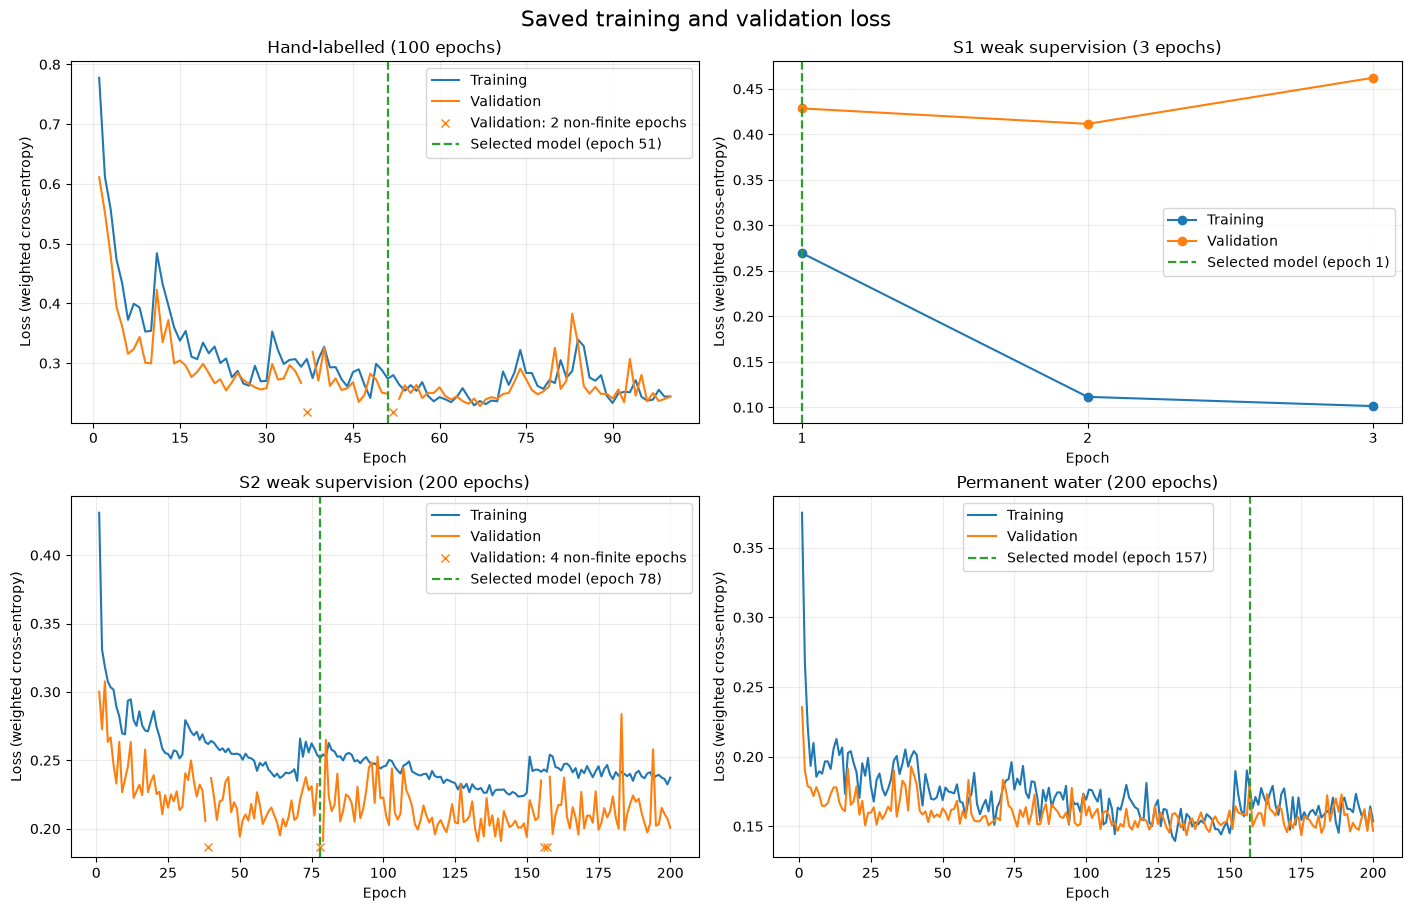

In [20]:
# Use the saved histories defined above; no training or evaluation is rerun.
history_paths = {
    "Hand-labelled": my_handlabeled_history,
    "S1 weak supervision": my_s1weak_history,
    "S2 weak supervision": my_s2weak_history,
    "Permanent water": my_perm_history,
}

# Use the checkpoint chosen for evaluation, rather than the minimum plotted loss.
# The training run selected checkpoints using validation IoU.
checkpoint_paths = {
    "Hand-labelled": my_handlabeled_cp,
    "S1 weak supervision": my_s1weak_cp,
    "S2 weak supervision": my_s2weak_cp,
    "Permanent water": my_perm_cp,
}

# Plot the recorded loss at each epoch without smoothing or rescaling it.
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
for ax, (name, history_path) in zip(axes.flat, history_paths.items()):
    history = json.loads(Path(history_path).read_text(encoding="utf-8"))
    history = sorted(history, key=lambda row: row["epoch"])
    epochs = np.array([row["epoch"] for row in history])

    for prefix, label, color in (
        ("training", "Training", "tab:blue"),
        ("validation", "Validation", "tab:orange"),
    ):
        losses = np.array([row[f"{prefix}_loss"] for row in history], dtype=float)
        missing = ~np.isfinite(losses)
        # Leave NaN/Inf as gaps, rather than interpolating or replacing them with zero.
        losses[missing] = np.nan
        ax.plot(epochs, losses, label=label, color=color,
                marker="o" if len(epochs) <= 10 else None, linewidth=1.5)
        if missing.any():
            # Marks use axes height, not loss values; they identify the missing epochs.
            ax.plot(epochs[missing], np.full(missing.sum(), 0.03),
                    linestyle="none", marker="x", color=color,
                    transform=ax.get_xaxis_transform(),
                    label=f"{label}: {missing.sum()} non-finite epochs")

    # Checkpoint filenames store the same one-based epochs as the saved history.
    match = re.search(r"_epoch(\d+)_", Path(checkpoint_paths[name]).name)
    if match is None:
        raise ValueError(f"Cannot read selected epoch from {checkpoint_paths[name]}")
    selected_epoch = int(match.group(1))
    if selected_epoch not in epochs:
        raise ValueError(f"Selected epoch {selected_epoch} is absent from {history_path}")
    ax.axvline(selected_epoch, color="tab:green", linestyle="--", linewidth=1.6,
               label=f"Selected model (epoch {selected_epoch})")

    # Separate axes accommodate different run lengths and loss ranges.
    ax.set_title(f"{name} ({len(history)} epochs)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (weighted cross-entropy)")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle("Saved training and validation loss", fontsize=16)
plt.show()


Hand-labelled: OK - selected epoch 51, validation IoU 0.539782; maximum 0.539782 at epoch(s) [51]
S1 weak supervision: OK - selected epoch 1, validation IoU 0.438605; maximum 0.438605 at epoch(s) [1]
S2 weak supervision: OK - selected epoch 78, validation IoU 0.619410; maximum 0.619410 at epoch(s) [78]
Permanent water: OK - selected epoch 157, validation IoU 0.854816; maximum 0.854816 at epoch(s) [157]


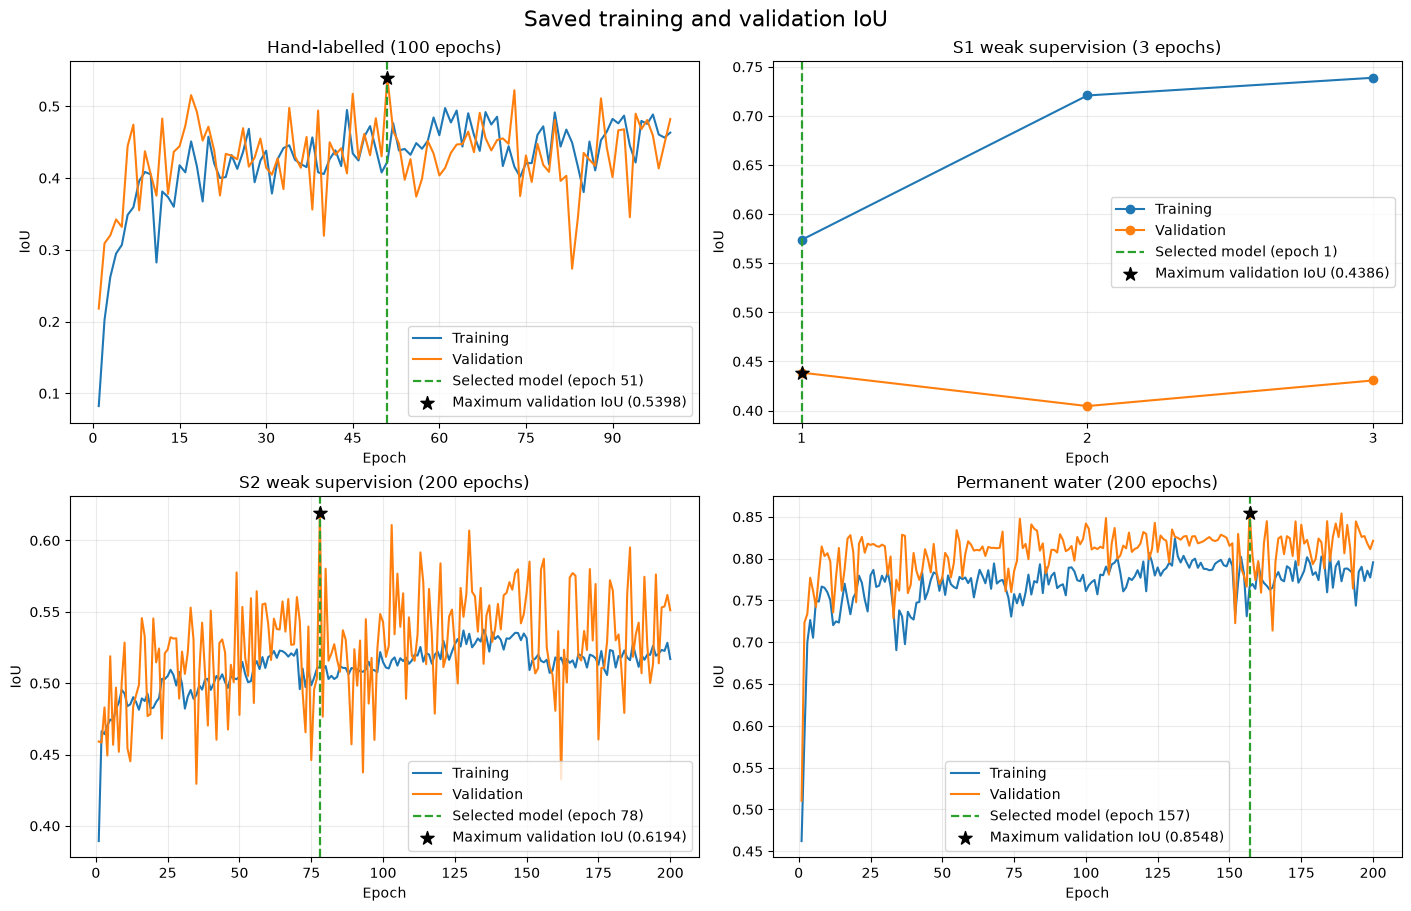

In [21]:
# Use the saved histories defined above; no training or evaluation is rerun.
history_paths = {
    "Hand-labelled": my_handlabeled_history,
    "S1 weak supervision": my_s1weak_history,
    "S2 weak supervision": my_s2weak_history,
    "Permanent water": my_perm_history,
}

# Read the selected epoch from the checkpoint filename independently of the history.
# The training run selected checkpoints using validation IoU.
checkpoint_paths = {
    "Hand-labelled": my_handlabeled_cp,
    "S1 weak supervision": my_s1weak_cp,
    "S2 weak supervision": my_s2weak_cp,
    "Permanent water": my_perm_cp,
}

# Plot recorded IoU without smoothing; leave non-finite values as gaps.
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
for ax, (name, history_path) in zip(axes.flat, history_paths.items()):
    history = json.loads(Path(history_path).read_text(encoding="utf-8"))
    history = sorted(history, key=lambda row: row["epoch"])
    epochs = np.array([row["epoch"] for row in history])

    for prefix, label, color in (
        ("training", "Training", "tab:blue"),
        ("validation", "Validation", "tab:orange"),
    ):
        ious = np.array([row[f"{prefix}_iou"] for row in history], dtype=float)
        missing = ~np.isfinite(ious)
        # Leave NaN/Inf as gaps, rather than interpolating or replacing them with zero.
        ious[missing] = np.nan
        ax.plot(epochs, ious, label=label, color=color,
                marker="o" if len(epochs) <= 10 else None, linewidth=1.5)
        if missing.any():
            # Marks use axes height, not IoU values; they identify the missing epochs.
            ax.plot(epochs[missing], np.full(missing.sum(), 0.03),
                    linestyle="none", marker="x", color=color,
                    transform=ax.get_xaxis_transform(),
                    label=f"{label}: {missing.sum()} non-finite epochs")

    # Checkpoint filenames store the same one-based epochs as the saved history.
    match = re.search(r"_epoch(\d+)_", Path(checkpoint_paths[name]).name)
    if match is None:
        raise ValueError(f"Cannot read selected epoch from {checkpoint_paths[name]}")
    selected_epoch = int(match.group(1))
    if selected_epoch not in epochs:
        raise ValueError(f"Selected epoch {selected_epoch} is absent from {history_path}")
    ax.axvline(selected_epoch, color="tab:green", linestyle="--", linewidth=1.6,
               label=f"Selected model (epoch {selected_epoch})")

    # Independently compare the selected epoch with all finite validation scores.
    validation_iou = np.array([row["validation_iou"] for row in history], dtype=float)
    finite = np.isfinite(validation_iou)
    if not finite.any():
        raise ValueError(f"No finite validation IoU in {history_path}")
    maximum_iou = validation_iou[finite].max()
    maximum_epochs = epochs[finite & (validation_iou == maximum_iou)]
    selected_iou = validation_iou[np.flatnonzero(epochs == selected_epoch)[0]]
    matches_maximum = bool(np.isfinite(selected_iou) and selected_iou == maximum_iou)
    # Mark the actual maximum separately so a mismatched checkpoint remains visible.
    ax.scatter(maximum_epochs, np.full(len(maximum_epochs), maximum_iou),
               color="black", marker="*", s=100, zorder=5,
               label=f"Maximum validation IoU ({maximum_iou:.4f})")
    verification = "OK" if matches_maximum else "MISMATCH"
    print(f"{name}: {verification} - selected epoch {selected_epoch}, "
          f"validation IoU {selected_iou:.6f}; maximum {maximum_iou:.6f} "
          f"at epoch(s) {maximum_epochs.tolist()}")

    # Separate axes accommodate different run lengths and IoU ranges.
    ax.set_title(f"{name} ({len(history)} epochs)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("IoU")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle("Saved training and validation IoU", fontsize=16)
plt.show()


In [22]:
# Inspect the exact saved entries without changing the historical metrics.
s2_history = json.loads(Path(my_s2weak_history).read_text(encoding="utf-8"))
for row in s2_history:
    if row["epoch"] in (77, 78, 79):
        print({key: row[key] for key in (
            "epoch", "validation_loss", "validation_iou", "validation_accuracy",
        )})
# A historical maximum is not sufficient to certify an unaffected checkpoint.
print("Epoch 78 requires corrected validation:", any(
    not np.isfinite(row[key]) for row in s2_history if row["epoch"] == 78
    for key in ("validation_loss", "validation_accuracy")
))


{'epoch': 77, 'validation_loss': 0.2326296716928482, 'validation_iou': 0.5037875771522522, 'validation_accuracy': 0.9170054197311401}
{'epoch': 78, 'validation_loss': nan, 'validation_iou': 0.6194095015525818, 'validation_accuracy': nan}
{'epoch': 79, 'validation_loss': 0.1912001073360443, 'validation_iou': 0.47651752829551697, 'validation_accuracy': 0.9240688681602478}
Epoch 78 requires corrected validation: True


In [23]:
# Reuse only preprocessing, dataset and model-conversion definitions from V2.
# No training cells, package installation, downloads or optimizer code are executed.
validation_source = Path("fcnn_training_v2.ipynb")
training_notebook = json.loads(validation_source.read_text(encoding="utf-8"))
required_definitions = {
    "sanitize_label_array", "mask_to_pil", "mask_pil_to_long", "processTestIm",
    "Sen1FloodsPathDataset", "convertBNtoGN",
}
definitions = []
for cell in training_notebook["cells"]:
    if cell["cell_type"] == "code":
        tree = ast.parse("".join(cell["source"]))
        definitions.extend(node for node in tree.body
                           if isinstance(node, (ast.FunctionDef, ast.ClassDef))
                           and node.name in required_definitions)
assert {node.name for node in definitions} == required_definitions
VALID_TARGET_VALUES = {0, 1, 255}
# Keep extracted definitions in an explicit namespace, then bind the names used below.
# Explicit assignments also let Pylance recognise these dynamically loaded objects.
validation_definitions = {
    "np": np, "torch": torch, "nn": nn, "Image": Image,
    "transforms": transforms, "F": F, "rasterio": rasterio,
    "VALID_TARGET_VALUES": VALID_TARGET_VALUES,
}
exec(compile(ast.Module(body=definitions, type_ignores=[]), str(validation_source), "exec"),
     validation_definitions)
Sen1FloodsPathDataset = validation_definitions["Sen1FloodsPathDataset"]
processTestIm = validation_definitions["processTestIm"]
convertBNtoGN = validation_definitions["convertBNtoGN"]

# Every candidate sees the same CSV order, batch size and complete validation split.
validation_csv = Path(split_handlabeled) / "flood_valid_data.csv"
hand_data = Path(dataset_path) / "data/flood_events/HandLabeled"
with validation_csv.open(newline="") as stream:
    validation_pairs = [(hand_data / "S1Hand" / row[0], hand_data / "LabelHand" / row[1])
                        for row in csv.reader(stream) if row]
validation_dataset = Sen1FloodsPathDataset(validation_pairs, processTestIm, "flood")

def collate_validation(samples):
    return torch.cat([x for x, y in samples]), torch.cat([y for x, y in samples])

corrected_loader = torch.utils.data.DataLoader(
    validation_dataset, batch_size=4, shuffle=False, drop_last=False,
    num_workers=0, collate_fn=collate_validation,
)
# Search all saved S2 candidates; do not infer quality from the rounded filename score.
s2_candidates = sorted(Path("runs/checkpoints/s2_weak").glob("Sen1Floods11_s2_weak_epoch*.cp"))
if not s2_candidates:
    raise FileNotFoundError("No saved S2 Weak candidates in runs/checkpoints/s2_weak")
if not any(path.name == my_s2weak_cp.name for path in s2_candidates):
    s2_candidates.append(my_s2weak_cp)

# Build the exact two-channel, two-class FCN with GroupNorm, without pretrained downloads.
validation_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
validation_model = models.segmentation.fcn_resnet50(weights=None, weights_backbone=None, num_classes=2)
validation_model.backbone.conv1 = nn.Conv2d(2, 64, 7, stride=2, padding=3, bias=False)
validation_model = convertBNtoGN(validation_model).to(validation_device).eval()
print(f"Corrected validation: {len(validation_pairs)} chips, {len(s2_candidates)} checkpoints, {validation_device}")


Corrected validation: 89 chips, 8 checkpoints, cpu


In [24]:
# Mean batch IoU retains the baseline aggregation, with empty batches excluded.
# Global IoU is also reported because mean batch IoU depends on the grouping of chips.
# Fixed CSV order makes this a new controlled comparison, not a replay of epoch 78.

'''
def corrected_validation(model, loader, device):
    batch_ious, batch_losses, batch_accuracies = [], [], []
    total_intersection = total_union = total_correct = total_valid = 0
    ignored_chips = skipped_batches = 0
    weight = torch.tensor([1.0, 8.0], device=device)
    with torch.inference_mode():
        for images, labels in loader:
            ignored_chips += int((labels.reshape(-1, 4, 256, 256) != 255).flatten(1).sum(1).eq(0).sum())
            keep = labels != 255
            if not keep.any():
                skipped_batches += 1
                continue
            labels = labels.long().to(device)
            keep = keep.to(device)
            logits = model(images.to(device))["out"]
            if not torch.isfinite(logits).all():
                raise FloatingPointError("Non-finite validation logits")
            loss = nn.functional.cross_entropy(logits, labels, weight=weight, ignore_index=255)
            prediction = logits.argmax(1)
            intersection = int(((prediction == 1) & (labels == 1) & keep).sum())
            union = int((((prediction == 1) | (labels == 1)) & keep).sum())
            valid = int(keep.sum())
            correct = int(((prediction == labels) & keep).sum())
            batch_ious.append((intersection + 1e-7) / (union + 1e-7))
            batch_losses.append(float(loss))
            batch_accuracies.append(correct / valid)
            total_intersection += intersection
            total_union += union
            total_correct += correct
            total_valid += valid
    if not batch_ious:
        raise ValueError("No supervised validation batches")
    return {
        "mean_batch_iou": float(np.mean(batch_ious)),
        "global_iou": total_intersection / total_union if total_union else None,
        "mean_batch_loss": float(np.mean(batch_losses)),
        "mean_batch_accuracy": float(np.mean(batch_accuracies)),
        "global_accuracy": total_correct / total_valid,
        "valid_pixels": total_valid, "ignored_chips": ignored_chips,
        "supervised_batches": len(batch_ious), "skipped_batches": skipped_batches,
    }

# Check the empty-batch guard without calling a model.
def fail_if_called(images):
    raise AssertionError("An all-ignore batch must never reach the model")
try:
    corrected_validation(fail_if_called, [(torch.zeros(4, 2, 256, 256),
                         torch.full((4, 256, 256), 255))], validation_device)
except ValueError as error:
    assert str(error) == "No supervised validation batches"

corrected_s2_results = []
for checkpoint_path in s2_candidates:
    weights = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
    validation_model.load_state_dict(weights, strict=True)
    del weights
    result = corrected_validation(validation_model, corrected_loader, validation_device)
    result.update(checkpoint=str(checkpoint_path),
                  epoch=int(re.search(r"_epoch(\d+)_", checkpoint_path.name).group(1)),
                  sha256=hashlib.sha256(checkpoint_path.read_bytes()).hexdigest())
    corrected_s2_results.append(result)
    print(f"Epoch {result['epoch']:3}: corrected mean batch IoU={result['mean_batch_iou']:.6f}, "
          f"global IoU={result['global_iou']:.6f}, skipped batches={result['skipped_batches']}", flush=True)

# Select among available saved candidates, not among unsaved epochs.
corrected_s2_best = max(corrected_s2_results, key=lambda row: row["mean_batch_iou"])
corrected_s2_checkpoint = Path(corrected_s2_best["checkpoint"])
print(f"Corrected selection: epoch {corrected_s2_best['epoch']} ({corrected_s2_checkpoint.name})")
# Keep historical selections and files intact; use this separate path for corrected evaluation.
# The exact historic shuffle is unavailable, so the arithmetic correction is not a measured score.
corrected_s2_report = {
    "protocol": "flood_valid_data.csv order; 4 chips/batch; skip zero-supervision batches; mean batch IoU",
    "source_sha256": hashlib.sha256(validation_source.read_bytes()).hexdigest(),
    "split_sha256": hashlib.sha256(validation_csv.read_bytes()).hexdigest(),
    "device": str(validation_device), "torch_version": torch.__version__,
    "selection_metric": "mean_batch_iou", "selected_checkpoint": str(corrected_s2_checkpoint),
    "candidates": corrected_s2_results,
}
# Save separately from the historical training and test results.
corrected_report_path = Path(my_results_path) / "s2_weak/corrected_validation_checkpoints.json"
corrected_report_path.write_text(json.dumps(corrected_s2_report, indent=2, allow_nan=False) + "\n", encoding="utf-8")
del validation_model
if validation_device.type == "cuda":
    torch.cuda.empty_cache()
'''

<>:64: SyntaxWarning: invalid escape sequence '\d'
<>:64: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Stefano\AppData\Local\Temp\ipykernel_18796\3930528483.py:64: SyntaxWarning: invalid escape sequence '\d'
  epoch=int(re.search(r"_epoch(\d+)_", checkpoint_path.name).group(1)),


'\ndef corrected_validation(model, loader, device):\n    batch_ious, batch_losses, batch_accuracies = [], [], []\n    total_intersection = total_union = total_correct = total_valid = 0\n    ignored_chips = skipped_batches = 0\n    weight = torch.tensor([1.0, 8.0], device=device)\n    with torch.inference_mode():\n        for images, labels in loader:\n            ignored_chips += int((labels.reshape(-1, 4, 256, 256) != 255).flatten(1).sum(1).eq(0).sum())\n            keep = labels != 255\n            if not keep.any():\n                skipped_batches += 1\n                continue\n            labels = labels.long().to(device)\n            keep = keep.to(device)\n            logits = model(images.to(device))["out"]\n            if not torch.isfinite(logits).all():\n                raise FloatingPointError("Non-finite validation logits")\n            loss = nn.functional.cross_entropy(logits, labels, weight=weight, ignore_index=255)\n            prediction = logits.argmax(1)\n         

## Evaluation